In [1]:
# region Imports

#* --------------------------------------------------------------------------------
#* General purpose imports
#* --------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import fisher_exact, barnard_exact
from matplotlib.ticker import FuncFormatter
import pickle as pkl


#* --------------------------------------------------------------------------------
#* Personal librairies imports
#* --------------------------------------------------------------------------------
import sys, os
src_path = os.path.abspath(os.path.join("..", "src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)
from utils import astro_utils as au
from utils import maths_utils  as mu
from utils import stats_utils  as su
from utils import graphics_utils  as gu
from utils import labels_utils  as lu
from utils import pandas_utils  as pu


#* --------------------------------------------------------------------------------
#* Project modules imports
#* --------------------------------------------------------------------------------
import sSFR
import generate_report as report
import domination

#* --------------------------------------------------------------------------------
#* Global variables
#* --------------------------------------------------------------------------------
import config as co

#* --------------------------------------------------------------------------------
#* Project data
#* --------------------------------------------------------------------------------

with open(co.DATA_PATH + co.PROCESS_SAMPLES, "rb") as file:
            sample = pkl.load(file)



# endregion

Done


In [2]:
import data_loader as dl
prev = dl.load_previous_samples()

312 objects loaded from CG4_Gals
2796 objects loaded from Control4B_Gals
3008 objects loaded from Control4C_Gals
224 objects loaded from RG4_Gals
78 objects loaded from CG4_Groups
699 objects loaded from Control4B_Groups
752 objects loaded from Control4C_Groups
56 objects loaded from RG4_Groups


In [3]:
def loc_agg(x):
    M_virial = pu.M_virial(x,co.cosmo,Vdisp)
    t_cr = pu.t_cr(size_Group_Bary_kpc,Vdisp)

In [4]:
quantities = ['t_cr', 'M_virial', 'Lum_group', 'M_virial_over_L']

In [5]:
tmp = sample['CG4_Groups'][quantities+['Class']]
tmp2 = sample['Control4B_Groups'][quantities]
tmp2 = tmp2.assign(Class='$Control_{4B}$')
# tmp3 = sample['Control4C_Groups'][['t_cr', 'M_virial_over_L']]
# tmp3 = tmp3.assign(Class='$Control_4C$')
tmp4 = sample['RG4_Groups'][quantities]
tmp4 = tmp4.assign(Class='$RG_4$')
# tmp = pd.concat([tmp, tmp2, tmp3, tmp4], ignore_index=True)
tmp = pd.concat([tmp, tmp2, tmp4], ignore_index=True)

tmp['lg_t_cr'] = np.log10(tmp['t_cr'])
tmp['lg_M_virial'] = np.log10(tmp['M_virial'])
tmp['lg_Lum_group'] = np.log10(tmp['Lum_group'])
tmp['lg_M_virial_over_L'] = np.log10(tmp['M_virial_over_L'])

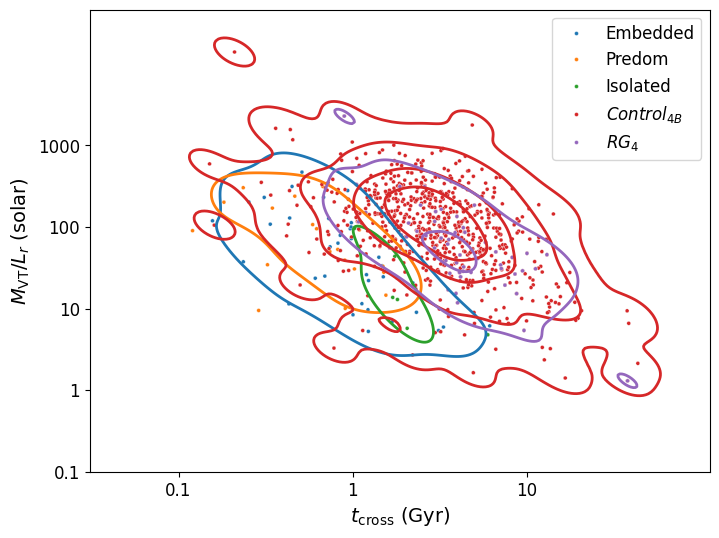

In [6]:

def log10_formatter(x, pos):
    # return rf"$10^{{{int(x)}}}$"
    return 10**int(x)

ticksize = 12
labelsize = 14
legendsize = 12
markersize = 8

fig, ax = plt.subplots(figsize=(8,6))

sns.scatterplot(
    data=tmp,
    x='lg_t_cr',
    y='lg_M_virial_over_L',
    hue='Class',
    s=markersize,
    ax=ax
)

sns.kdeplot(
    data=tmp,
    x='lg_t_cr',
    y='lg_M_virial_over_L',
    hue='Class',
    levels=5,
    color='k',
    linewidths=2,
    ax=ax
)

ax.set_xlabel(r'$t_\mathrm{cross}$ (Gyr)', fontsize=labelsize)
ax.set_ylabel(r'$M_\mathrm{VT}/L_r$ (solar)', fontsize=labelsize)

ax.tick_params(axis='both', labelsize=ticksize)

ax.set_xticks(np.arange(-1, 2))
ax.set_yticks(np.arange(-1, 4))

ax.xaxis.set_major_formatter(FuncFormatter(log10_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(log10_formatter))

ax.legend(fontsize=legendsize)

plt.savefig('/Users/matt/Downloads/tcr_MvirialOverL.pdf', dpi=300)

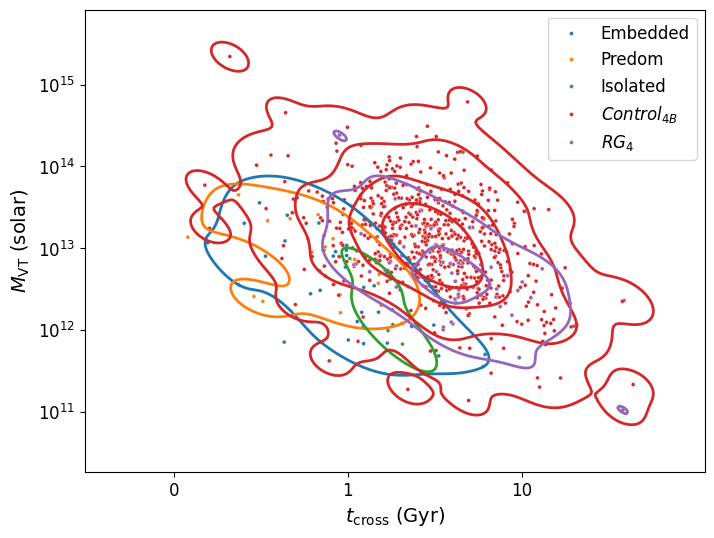

In [7]:


def log10_formatter(x, pos, n_min=-2,nmax=2):
    if x < n_min or x > nmax:
        return rf"$10^{{{int(x)}}}$"
    else:
        return f"{10**int(x):.0f}"
    # return 10**int(x)

ticksize = 12
labelsize = 14
legendsize = 12
markersize = 8

fig, ax = plt.subplots(figsize=(8,6))

sns.scatterplot(
    data=tmp,
    x='lg_t_cr',
    y='lg_M_virial',
    hue='Class',
    s=markersize,
    ax=ax
)

sns.kdeplot(
    data=tmp,
    x='lg_t_cr',
    y='lg_M_virial',
    hue='Class',
    levels=5,
    color='k',
    linewidths=2,
    ax=ax
)

ax.set_xlabel(r'$t_\mathrm{cross}$ (Gyr)', fontsize=labelsize)
ax.set_ylabel(r'$M_\mathrm{VT}$ (solar)', fontsize=labelsize)

ax.tick_params(axis='both', labelsize=ticksize)

ax.set_xticks(np.arange(-1, 2))
ax.set_yticks(np.arange(11, 16))

ax.xaxis.set_major_formatter(FuncFormatter(log10_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(log10_formatter))

ax.legend(fontsize=legendsize)

plt.savefig('/Users/matt/Downloads/tcr_Mvirial.pdf', dpi=300)

In [8]:
def loc_agg(x):
    excess_median = np.median(x['sSFR_excess'])
    # M_overL_median = np.median(x['M_over_L'])
    has_quenched = np.sum(x['sSFR_status'] == 'Quenched') > 0
    # return pd.Series({'sSFR_excess_median': excess_median, 'M_over_L_median': M_overL_median, 'has_quenched': has_quenched})
    return pd.Series({'sSFR_excess_median': excess_median, 'has_quenched': has_quenched})

for cat in [name for name in co.SAMPLE.keys()]:
    gals = sample[cat+co.GASUFF]
    grp = sample[cat+co.GRSUFF]
    grp2 = gals.set_index('Group').groupby(level='Group').apply(loc_agg).reset_index()
    grp = grp.merge(grp2, on='Group', how='left')
    sample[cat + co.GRSUFF] = grp

In [9]:
for cat in [name+co.GRSUFF for name in co.SAMPLE.keys()]:
    df = sample[cat]
    print(f"Sample {cat}: sSFR excess median = {df['sSFR_excess_median'].median():.2f} -- exluding quenched: {df[df['has_quenched']==False]['sSFR_excess_median'].median():.2f}")

Sample CG4_Groups: sSFR excess median = -0.56 -- exluding quenched: -0.55
Sample Control4B_Groups: sSFR excess median = -0.30 -- exluding quenched: -0.27
Sample Control4C_Groups: sSFR excess median = -0.18 -- exluding quenched: -0.17
Sample RG4_Groups: sSFR excess median = 0.06 -- exluding quenched: 0.06


In [10]:
MS_coeffs = [-0.4374018  -5.77929189]



In [11]:
from scipy.stats import ranksums

In [12]:
CG = sample['CG4'+co.GASUFF][sample['CG4'+co.GASUFF]['sSFR_status']=='Starforming']
for cat in [name+co.GASUFF for name in co.SAMPLE.keys()]:
    df = sample[cat][sample[cat]['sSFR_status']=='Starforming']
    print(f"Sample {cat}: MS offset median = {df['sSFR_MS_offset'].median():.2f}")
    if cat != 'CG4_Gals':
        if (df['sSFR_MS_offset'].median() < CG['sSFR_MS_offset'].median()):
            alternative = 'less'
        else:
            alternative = 'greater'
        statistic, p_value = ranksums(df['sSFR_MS_offset'],CG['sSFR_MS_offset'], alternative=alternative)
        print(f"  -- Wilcoxon test vs CG4: statistic={statistic:.2f}, p-value={p_value:.4f}")  

Sample CG4_Gals: MS offset median = 0.02
Sample Control4B_Gals: MS offset median = -0.02
  -- Wilcoxon test vs CG4: statistic=-0.75, p-value=0.2269
Sample Control4C_Gals: MS offset median = -0.06
  -- Wilcoxon test vs CG4: statistic=-1.94, p-value=0.0260
Sample RG4_Gals: MS offset median = -0.01
  -- Wilcoxon test vs CG4: statistic=-0.06, p-value=0.4757


In [13]:
from itertools import combinations

In [14]:
# same, but for CG4 classes
df = sample['CG4'+co.GASUFF][(sample['CG4'+co.GASUFF]['sSFR_status']=='Starforming')]
CG_per_class ={}
for Class in sample['CG4_Groups']['Class'].unique():
    grp = sample['CG4_Groups'][sample['CG4_Groups']['Class']==Class]['Group'].unique()
    CG_per_class[Class] = df[(df['Group'].isin(grp))]
    print(f"CG4 {Class}: MS offset median = {CG_per_class[Class]['sSFR_MS_offset'].median():.2f} ({CG_per_class[Class].shape[0]} galaxies)")

CG4 Embedded: MS offset median = -0.00 (52 galaxies)
CG4 Predom: MS offset median = 0.12 (18 galaxies)
CG4 Isolated: MS offset median = 0.10 (14 galaxies)


In [15]:
for cl1,cl2 in combinations(CG_per_class.keys(), 2):
    if (CG_per_class[cl1]['sSFR_MS_offset'].median() < CG_per_class[cl2]['sSFR_MS_offset'].median()):
        alternative = 'less'
    else:
        alternative = 'greater'

    statistic, p_value = ranksums(CG_per_class[cl1]['sSFR_MS_offset'],CG_per_class[cl2]['sSFR_MS_offset'], alternative=alternative)
    print(f"Wilcoxon test {cl1} vs {cl2}: statistic={statistic:.2f}, p-value={p_value:.4f}")  

Wilcoxon test Embedded vs Predom: statistic=-0.85, p-value=0.1986
Wilcoxon test Embedded vs Isolated: statistic=-1.38, p-value=0.0837
Wilcoxon test Predom vs Isolated: statistic=-0.42, p-value=0.6620


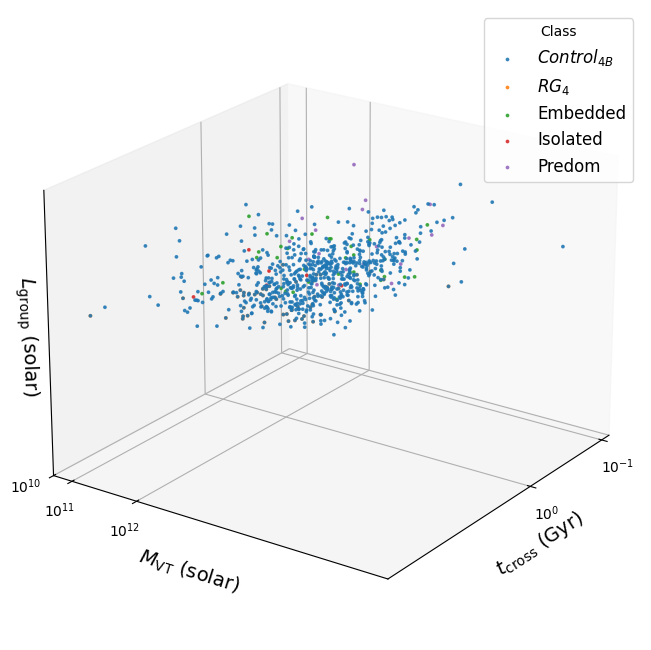

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
from matplotlib.ticker import FuncFormatter

# --- tick formatter (same logic as your 2D case)
def log10_formatter(x, pos):
    return rf"$10^{{{int(x)}}}$"

pointsize = 3

x = tmp['lg_t_cr'].to_numpy()
y = tmp['lg_M_virial'].to_numpy()
z = tmp['lg_Lum_group'].to_numpy()

classes = tmp['Class'].astype(str).to_numpy()
uniq = np.unique(classes)

# --- figure
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# plot per class (clean legend)
for c in uniq:
    m = classes == c
    ax.scatter(
        x[m], y[m], z[m],
        s=pointsize,
        alpha=0.8,
        label=c
    )

# --- labels
ax.set_xlabel(r'$t_\mathrm{cross}$ (Gyr)', fontsize=14)
ax.set_ylabel(r'$M_\mathrm{VT}$ (solar)', fontsize=14)
ax.set_zlabel(r'$L_\mathrm{group}$ (solar)', fontsize=14, rotation=270,labelpad=-12)

# --- ticks (choose ranges adapted to your data)
ax.set_xticks(np.arange(-1, 1))
ax.set_yticks(np.arange(11, 13))
ax.set_zticks(np.arange(10, 11))

ax.xaxis.set_major_formatter(FuncFormatter(log10_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(log10_formatter))
ax.zaxis.set_major_formatter(FuncFormatter(log10_formatter))

# --- view angle (important!)
ax.view_init(elev=22, azim=35)

ax.legend(title='Class', fontsize=12)
plt.subplots_adjust(left=0.18, right=0.98, bottom=0.08, top=0.98)

plt.savefig('/Users/matt/Downloads/tcr_Mvirial_Lgroup_3D.pdf', dpi=300)
plt.show()